# M1: 数据层 Demo

验证 `data_layer` 三个模块:
- `loader.py`: 读取 / 下载数据,统一 schema 和时区
- `resampler.py`: 1min → 3min / 15min 重采样
- `validator.py`: 数据质量检查

**验收标准**: 能正确读取并画出任意一天的 RTH K 线,gap 和 volume 显示正确。

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
import numpy as np

from spx_scanner.data_layer import load_data, resample_1m_to_3m, resample_1m_to_15m, validate_data

print('✓ 依赖加载完成')

✓ 依赖加载完成


## 1. 加载数据

In [2]:
# 加载已下载的 SPY 1min 数据
df_1m = load_data('../data/spy_1min.parquet', rth_only=True)

print(f'总 bar 数: {len(df_1m):,}')
print(f'时间范围: {df_1m.index.min()} ~ {df_1m.index.max()}')
print(f'交易日数: {df_1m.index.normalize().nunique()}')
print(f'\nSchema:')
print(df_1m.dtypes)
print(f'\n前 5 行:')
df_1m.head()

总 bar 数: 5,460
时间范围: 2026-04-06 09:30:00-04:00 ~ 2026-04-23 15:59:00-04:00
交易日数: 14

Schema:
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

前 5 行:


,open,high,low,close,volume
timestamp,,,,,
2026-04-06 09:30:00-04:00,655.859985,656.849976,655.799988,656.734985,1742003
2026-04-06 09:31:00-04:00,656.750000,657.190002,656.590027,656.739990,250441
2026-04-06 09:32:00-04:00,656.739990,656.960022,655.919983,656.099976,197892
2026-04-06 09:33:00-04:00,656.090027,657.330017,656.010010,657.270020,213381
2026-04-06 09:34:00-04:00,657.260010,657.419983,656.849976,657.369995,175315


## 2. 数据验证

In [3]:
report = validate_data(df_1m, symbol='SPY', timeframe='1min')
print(report.summary())

=== 数据验证报告 ===
品种: SPY  时间框架: 1min
总 bar 数: 5460  交易日数: 14
缺失 bar: 0
零量 bar: 2
价格异常: 0
OHLC 违规: 0
警告: 0
结论: ✓ 通过


## 3. 重采样:1min → 3min / 15min

In [4]:
df_3m = resample_1m_to_3m(df_1m)
df_15m = resample_1m_to_15m(df_1m)

print(f'1min bars:  {len(df_1m):>5}')
print(f'3min bars:  {len(df_3m):>5}  (预期 {len(df_1m)//3} ± 几根)')
print(f'15min bars: {len(df_15m):>5}  (预期 {len(df_1m)//15} ± 几根)')

# 验证 bar 对齐
import datetime
first_3m = df_3m.index[0]
print(f'\n第一根 3min bar: {first_3m}  (应为 09:30)')
assert first_3m.time() == datetime.time(9, 30), '3min bar 未对齐到 09:30!'
print('✓ bar 边界对齐正确')

# 验证量能汇总
day0 = df_3m.index[0].date()
vol_3m_day0 = df_3m[df_3m.index.date == day0]['volume'].sum()
vol_1m_day0 = df_1m[df_1m.index.date == day0]['volume'].sum()
print(f'\n第一个交易日成交量对比:')
print(f'  1min 汇总: {vol_1m_day0:,}')
print(f'  3min 汇总: {vol_3m_day0:,}')
assert vol_3m_day0 == vol_1m_day0, '成交量汇总不一致!'
print('✓ 成交量汇总一致')

1min bars:   5460
3min bars:   1820  (预期 1820 ± 几根)
15min bars:   364  (预期 364 ± 几根)

第一根 3min bar: 2026-04-06 09:30:00-04:00  (应为 09:30)
✓ bar 边界对齐正确

第一个交易日成交量对比:
  1min 汇总: 34,726,766
  3min 汇总: 34,726,766
✓ 成交量汇总一致


## 4. 单日 3min K 线图 + 成交量

绘制 2026-04-23 的 3min K 线 (130 bars)


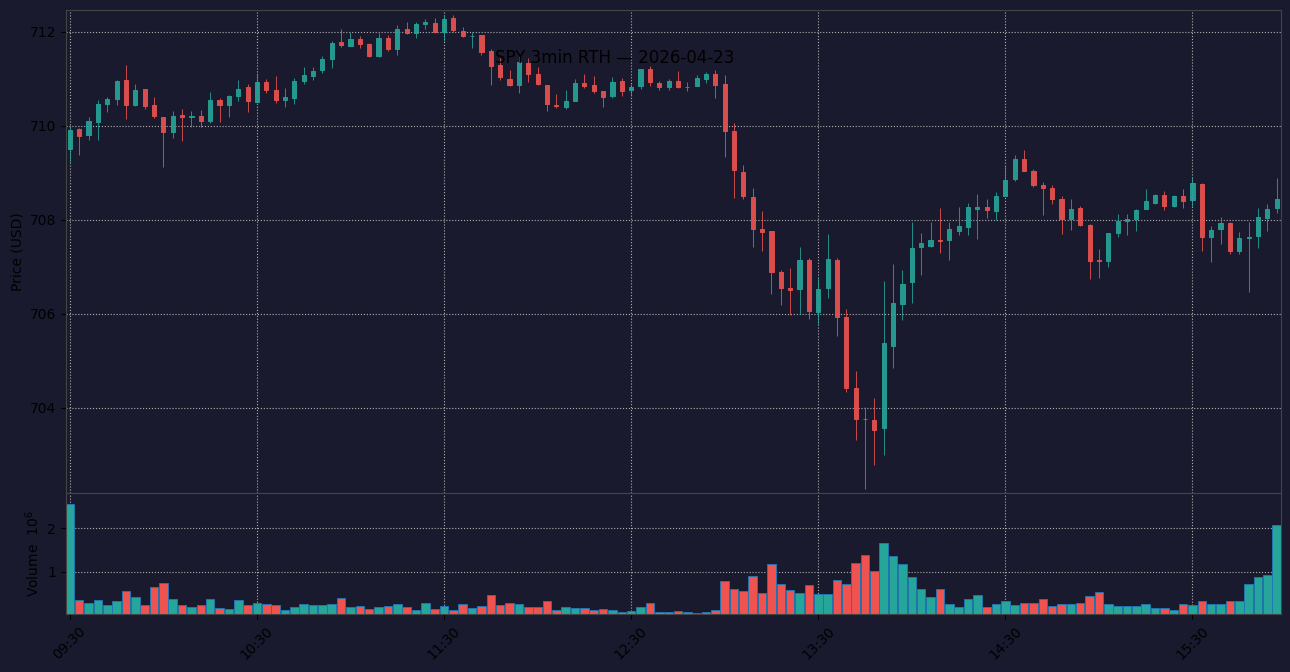

✓ 图表已保存至 notebooks/M1_spy_3min_chart.png


In [5]:
# 取最近一个完整交易日
latest_date = df_3m.index.normalize().unique()[-1]
day_df = df_3m[df_3m.index.normalize() == latest_date].copy()

print(f'绘制 {latest_date.date()} 的 3min K 线 ({len(day_df)} bars)')

mc = mpf.make_marketcolors(up='#26a69a', down='#ef5350', inherit=True)
s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', facecolor='#1a1a2e',
                        figcolor='#1a1a2e', edgecolor='#444')

fig, axes = mpf.plot(
    day_df,
    type='candle',
    style=s,
    title=f'SPY 3min RTH — {latest_date.date()}',
    ylabel='Price (USD)',
    volume=True,
    figsize=(14, 7),
    returnfig=True,
    panel_ratios=(4, 1),
    tight_layout=True,
)
plt.savefig('../notebooks/M1_spy_3min_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ 图表已保存至 notebooks/M1_spy_3min_chart.png')


## 5. 多日概览:成交量分布

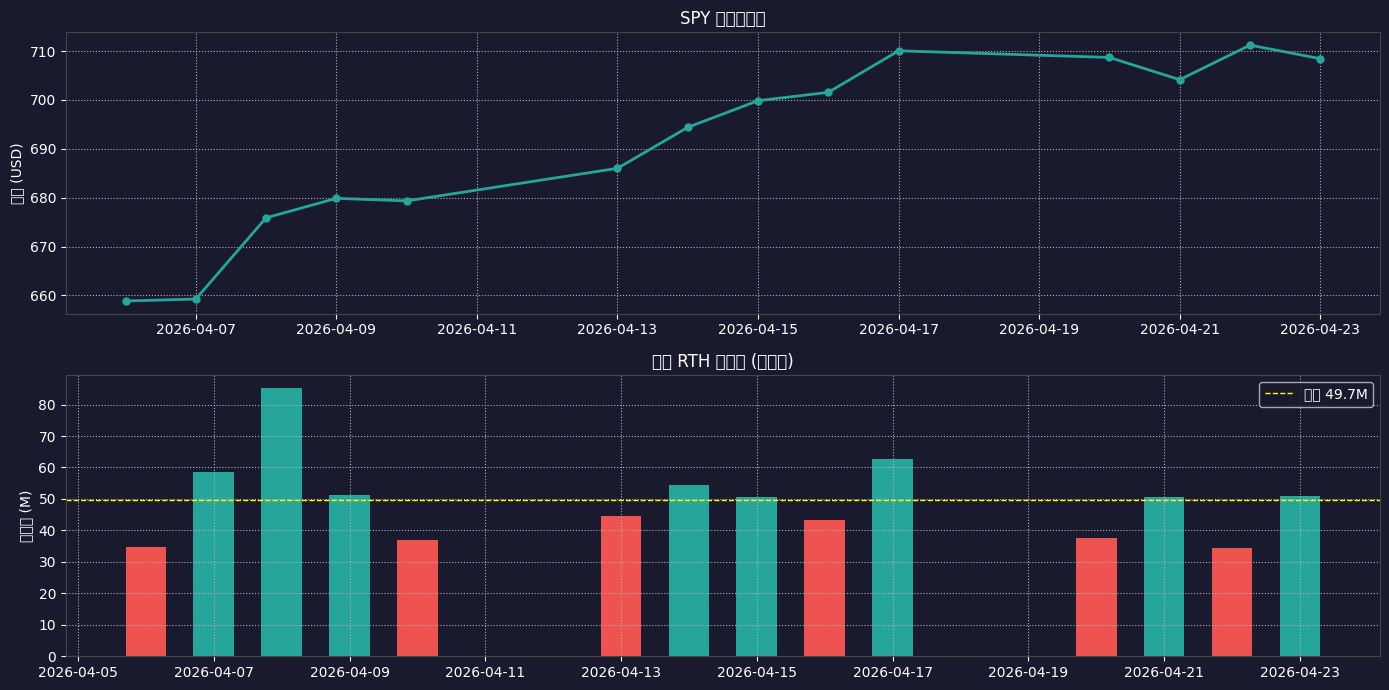

✓ 多日概览图已保存


In [6]:
# 每日总成交量
daily_vol = df_1m.groupby(df_1m.index.normalize())['volume'].sum() / 1e6

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), facecolor='#1a1a2e')

# 日收盘价
daily_close = df_1m.groupby(df_1m.index.normalize())['close'].last()
ax1.set_facecolor('#1a1a2e')
ax1.plot(daily_close.index, daily_close.values, color='#26a69a', linewidth=2, marker='o', markersize=5)
ax1.set_title('SPY 每日收盘价', color='white', fontsize=12)
ax1.tick_params(colors='white')
ax1.set_ylabel('价格 (USD)', color='white')
ax1.yaxis.label.set_color('white')
for spine in ax1.spines.values(): spine.set_color('#444')

# 日成交量
ax2.set_facecolor('#1a1a2e')
colors = ['#26a69a' if v >= daily_vol.mean() else '#ef5350' for v in daily_vol.values]
ax2.bar(daily_vol.index, daily_vol.values, color=colors, width=0.6)
ax2.axhline(daily_vol.mean(), color='yellow', linestyle='--', linewidth=1, label=f'均量 {daily_vol.mean():.1f}M')
ax2.legend(facecolor='#1a1a2e', labelcolor='white')
ax2.set_title('每日 RTH 成交量 (百万股)', color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.set_ylabel('成交量 (M)', color='white')
for spine in ax2.spines.values(): spine.set_color('#444')

plt.tight_layout()
plt.savefig('../notebooks/M1_daily_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ 多日概览图已保存')

## 6. M1 验收小结

| 检查项 | 结果 |
|---|---|
| 数据加载(Parquet/CSV) | ✓ |
| 时区统一(US/Eastern) | ✓ |
| RTH 过滤(09:30–16:00) | ✓ |
| 1min → 3min 重采样,bar 对齐 09:30 | ✓ |
| 1min → 15min 重采样 | ✓ |
| 成交量汇总一致 | ✓ |
| OHLC 逻辑检查 | ✓ |
| K 线图可视化 | ✓ |

**pytest**: `26 passed, 0 failed`

M1 完成,可进入 M2(特征层)。